In [226]:
import torch
import adabmDCA 
from adabmDCA.fasta import get_tokens, write_fasta
from adabmDCA.io import load_params, load_chains, import_from_fasta
from adabmDCA.utils import init_parameters, init_chains, get_device, get_dtype
from adabmDCA.functional import one_hot

import matplotlib.pyplot as plt
import numpy as np

from adabmDCA.statmech import compute_energy

In [35]:
def compute_seqID(a1: torch.Tensor, single_seq: torch.Tensor):
    """
    Computes the Hamming distance 
    between a set of one-hot encoded sequences and a single one-hot encoded sequence.

    Args:
        a1 (torch.Tensor): Sequence dataset, shape (N, L, C), where N is the number of sequences,
                           L is the length, and C is the number of categories (one-hot size).
        single_seq (torch.Tensor): Single one-hot encoded sequence, shape (L, C).

    Returns:
        torch.Tensor: Hamming distances for each sequence in the dataset.
    """
    # print(a1.shape, single_seq.shape)
    a1 = a1.view(a1.shape[0], -1)
    single_seq = single_seq.view(1, -1)
    # print(a1.shape, single_seq.shape)
    seqID = (a1 * single_seq).sum(1) 

    return seqID


In [26]:
# Set the device
device = get_device("cuda")
dtype = get_dtype("float32")

Running on NVIDIA RTX A4000


In [30]:
tokens = get_tokens('protein')
sample = load_chains("density=0.125_samples.fasta", tokens)
M_sanple, L, q = len(sample), len(sample[0]), len(tokens)
params = load_params("density=0.125_params.dat", tokens=tokens, device=device, dtype=dtype)
sample = one_hot(torch.tensor(sample, device=device, dtype=torch.int32), num_classes=q).to(dtype)

_, nat_data = import_from_fasta("../data/Chorismate_Mutase/CM_130530_MC.fasta", tokens=tokens, filter_sequences=True)
nat_data = one_hot(torch.tensor(nat_data, device=device, dtype=torch.int32), num_classes=q).to(dtype)

Unknown token found: removing sequence gi|297170754|gb|ADI21776.1| hypothetical protein [uncultured gamma proteobacterium HF0130_22O14]


In [51]:
divergence = torch.zeros(M_sanple, device=device, dtype=dtype)
output_file = "divergence_values.txt"

# Apri il file in modalità scrittura
with open(output_file, "w") as f:
    for i, sequence in enumerate(sample):
        # Calcola il valore di divergence per l'indice corrente
        divergence[i] = min(L - compute_seqID(nat_data, sequence)) / L
        
        # Ogni 10,000 iterazioni, salva i valori su file
        if i % 1_000 == 0 and i > 0:
            print(f"Saving progress at iteration {i}")
            # Scrive i valori fino a i in modo iterativo
            f.write("\n".join([str(val.item()) for val in divergence[i-1_000:i]]))
            f.write("\n")
    
    # Scrive gli ultimi valori rimanenti
    print("Saving remaining values")
    f.write("\n".join([str(val.item()) for val in divergence[i-(i % 1_000):i+1]]))
    f.write("\n")

print(f"Divergence values saved in {output_file}")


Saving progress at iteration 1000
Saving progress at iteration 2000
Saving progress at iteration 3000
Saving progress at iteration 4000
Saving progress at iteration 5000
Saving progress at iteration 6000
Saving progress at iteration 7000
Saving progress at iteration 8000
Saving progress at iteration 9000
Saving progress at iteration 10000
Saving progress at iteration 11000
Saving progress at iteration 12000
Saving progress at iteration 13000
Saving progress at iteration 14000
Saving progress at iteration 15000
Saving progress at iteration 16000
Saving progress at iteration 17000
Saving progress at iteration 18000
Saving progress at iteration 19000
Saving progress at iteration 20000
Saving progress at iteration 21000
Saving progress at iteration 22000
Saving progress at iteration 23000
Saving progress at iteration 24000
Saving progress at iteration 25000
Saving progress at iteration 26000
Saving progress at iteration 27000
Saving progress at iteration 28000
Saving progress at iteration 

In [ ]:
divergence_cpu = divergence.cpu()


In [71]:
divergence_cpu.shape

torch.Size([1000000])

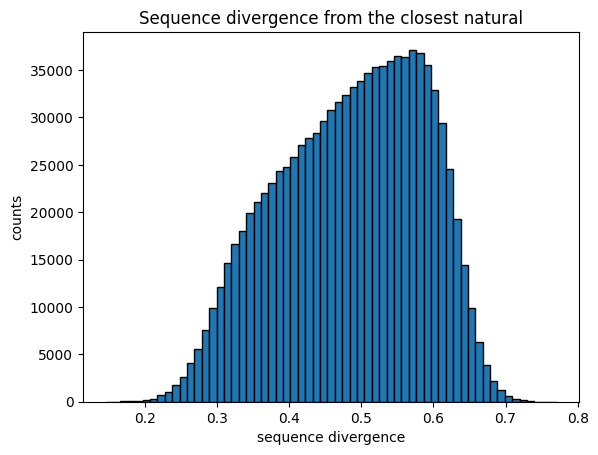

In [352]:
plt.hist(divergence_cpu, bins=61, edgecolor='black')

# Configurazione dell'istogramma
plt.title("Sequence divergence from the closest natural")
plt.xlabel("sequence divergence")
plt.ylabel("counts")

# Mostra il grafico
plt.savefig("divergence_histogram.png")
plt.show()


In [75]:
batch_size = 10000

results = []

# Itera sui batch
for i in range(0, sample.shape[0], batch_size):
    # Estrai il batch corrente
    batch = sample[i:i + batch_size]
    
    # Calcola l'energia per il batch
    batch_energy = compute_energy(batch, params)
    
    # Accumula i risultati
    results.append(batch_energy)

# Combina i risultati in un unico tensore
energies = torch.cat(results, dim=0)

print(f"Energies shape: {energies.shape}")

Energies shape: torch.Size([1000000])


In [192]:
energies_cpu = energies.cpu()

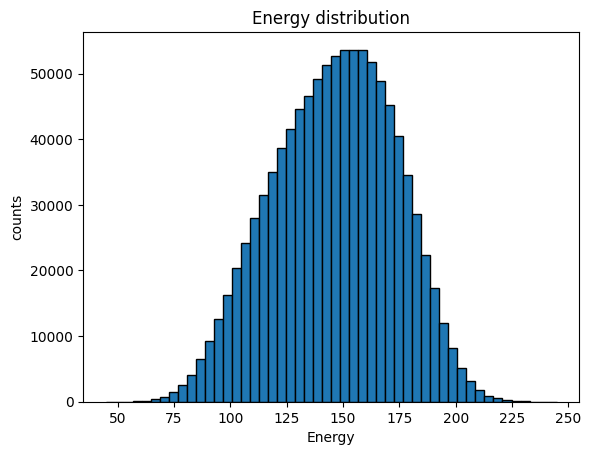

In [353]:
plt.hist(energies_cpu, bins=50, edgecolor='black')

# Configurazione dell'istogramma
plt.title("Energy distribution")
plt.xlabel("Energy")
plt.ylabel("counts")

# Mostra il grafico
plt.savefig("energy_histogram.png")
plt.show()

In [77]:
# Salva il tensore energies in un file .txt
output_file = "energies.txt"

# Scrivi il tensore in formato leggibile
with open(output_file, "w") as f:
    for energy in energies:
        f.write(f"{energy.item()}\n")

print(f"Energies salvate in {output_file}")


Energies salvate in energies.txt


In [195]:
sample_cpu = sample.cpu()

In [203]:
mask1 = (divergence_cpu > 0.2) & (divergence_cpu < 0.25)
mask2 = (divergence_cpu > 0.4) & (divergence_cpu < 0.45)
mask3 = (divergence_cpu > 0.6) & (divergence_cpu < 0.65)

In [209]:
sorted_indices1 = torch.argsort(energies_cpu[mask1])
batch1_sorted = sample[mask1][sorted_indices1]
energies1_sorted = energies_cpu[mask1][sorted_indices1]
div1_sorted = divergence_cpu[mask1][sorted_indices1]

sorted_indices2 = torch.argsort(energies_cpu[mask2])
batch2_sorted = sample[mask2][sorted_indices2]
energies2_sorted = energies_cpu[mask2][sorted_indices2]
div2_sorted = divergence_cpu[mask2][sorted_indices2]

sorted_indices3 = torch.argsort(energies_cpu[mask3])
batch3_sorted = sample[mask3][sorted_indices3]
energies3_sorted = energies_cpu[mask3][sorted_indices3]
div3_sorted = divergence_cpu[mask3][sorted_indices3]

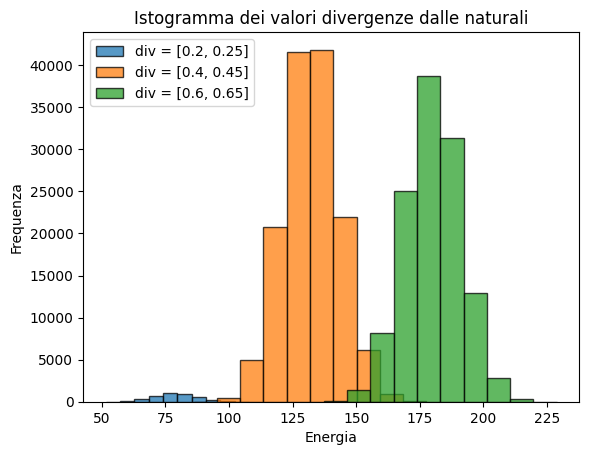

In [211]:
plt.hist(energy1_sorted,   edgecolor='black', label="div = [0.2, 0.25]", alpha=0.75)
plt.hist(energies2_sorted, edgecolor='black', label="div = [0.4, 0.45]", alpha=0.75)
plt.hist(energies3_sorted, edgecolor='black', label="div = [0.6, 0.65]", alpha=0.75)


# Configurazione dell'istogramma
plt.title("Istogramma dei valori divergenze dalle naturali")
plt.xlabel("Energia")
plt.ylabel("Frequenza")
plt.legend()
# Mostra il grafico
plt.show()

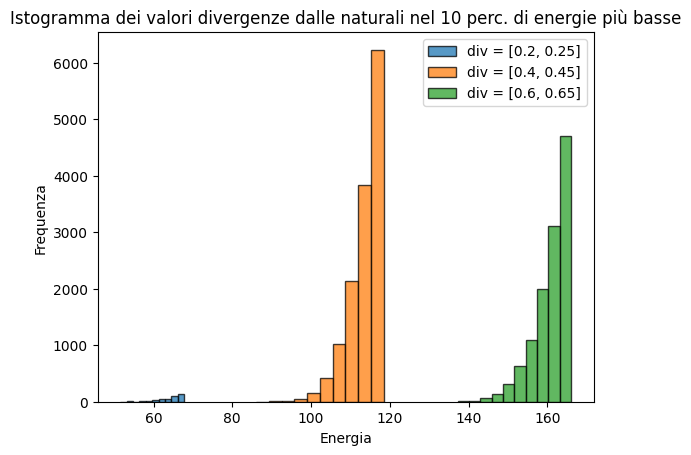

In [ ]:
batch1_low_energy = batch1_sorted[:int(0.1 * batch1_sorted.size(0))]
batch2_low_energy = batch2_sorted[:int(0.1 * batch2_sorted.size(0))]
batch3_low_energy = batch3_sorted[:int(0.1 * batch3_sorted.size(0))]

energies1_low = energies1_sorted[:int(0.1 * batch1_sorted.size(0))]
energies2_low = energies2_sorted[:int(0.1 * batch2_sorted.size(0))]
energies3_low = energies3_sorted[:int(0.1 * batch3_sorted.size(0))]

div1_low = div1_sorted[:int(0.1 * batch1_sorted.size(0))]
div2_low = div2_sorted[:int(0.1 * batch2_sorted.size(0))]
div3_low = div3_sorted[:int(0.1 * batch3_sorted.size(0))]

plt.hist(energies1_low, edgecolor='black', label="div = [0.2, 0.25]", alpha=0.75)
plt.hist(energies2_low, edgecolor='black', label="div = [0.4, 0.45]", alpha=0.75)
plt.hist(energies3_low, edgecolor='black', label="div = [0.6, 0.65]", alpha=0.75)

# Configurazione dell'istogramma

plt.title("Istogramma dei valori divergenze dalle naturali nel 10 perc. di energie più basse")
plt.xlabel("Energia")
plt.ylabel("Frequenza")
plt.legend()
# Mostra il grafico
plt.show()

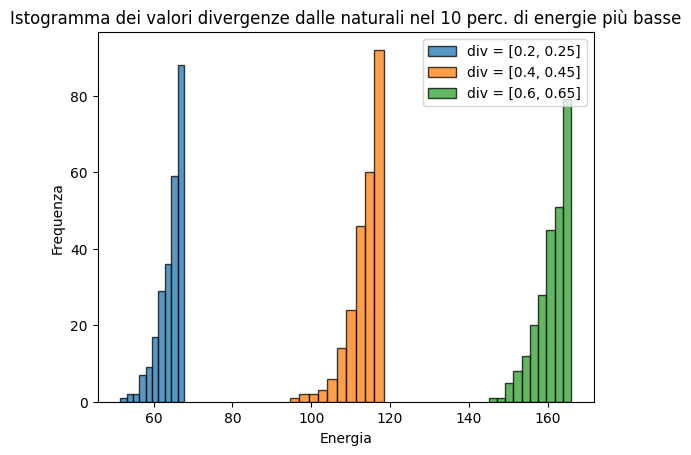

In [213]:
# Estrazione di 250 indici casuali
num_samples = 250
random_indices1 = torch.randperm(batch1_low_energy.size(0))[:num_samples] 
random_indices2 = torch.randperm(batch2_low_energy.size(0))[:num_samples] 
random_indices3 = torch.randperm(batch3_low_energy.size(0))[:num_samples] 

batch1_final = batch1_low_energy[random_indices1]
batch2_final = batch2_low_energy[random_indices2]
batch3_final = batch3_low_energy[random_indices3]

energies1_final = energies1_low[random_indices1]
energies2_final = energies2_low[random_indices2]
energies3_final = energies3_low[random_indices3]

div1_final = div1_low[random_indices1]
div2_final = div2_low[random_indices2]
div3_final = div3_low[random_indices3]

plt.hist(energies1_final, edgecolor='black', label="div = [0.2, 0.25]", alpha=0.75)
plt.hist(energies2_final, edgecolor='black', label="div = [0.4, 0.45]", alpha=0.75)
plt.hist(energies3_final, edgecolor='black', label="div = [0.6, 0.65]", alpha=0.75)

# Configurazione dell'istogramma
plt.title("Istogramma dei valori divergenze dalle naturali nel 10 perc. di energie più basse")
plt.xlabel("Energia")
plt.ylabel("Frequenza")
plt.legend()
# Mostra il grafico
plt.show()

In [222]:
result_strings1 = [
    f"batch 1 | seq {i+1} | DCAenergy {energies1_final[i].item():.4f} | normalized seq. divergence {div1_final[i].item():.4f}"
    for i in range(energies1_final.size(0))
]

result_strings2 = [
    f"batch 2 | seq {i+1} | DCAenergy {energies2_final[i].item():.4f} | normalized seq. divergence {div2_final[i].item():.4f}"
    for i in range(energies2_final.size(0))
]

result_strings3 = [
    f"batch 3 | seq {i+1} | DCAenergy {energies3_final[i].item():.4f} | normalized seq. divergence {div3_final[i].item():.4f}"
    for i in range(energies3_final.size(0))
]

In [ ]:
write_fasta("batch1.fasta", headers=result_strings1, sequences=torch.argmax(batch1_final, -1).cpu().numpy(), numeric_input=True, tokens=tokens)
write_fasta("batch2.fasta", headers=result_strings2, sequences=torch.argmax(batch2_final, -1).cpu().numpy(), numeric_input=True, tokens=tokens)
write_fasta("batch3.fasta", headers=result_strings3, sequences=torch.argmax(batch3_final, -1).cpu().numpy(), numeric_input=True, tokens=tokens)

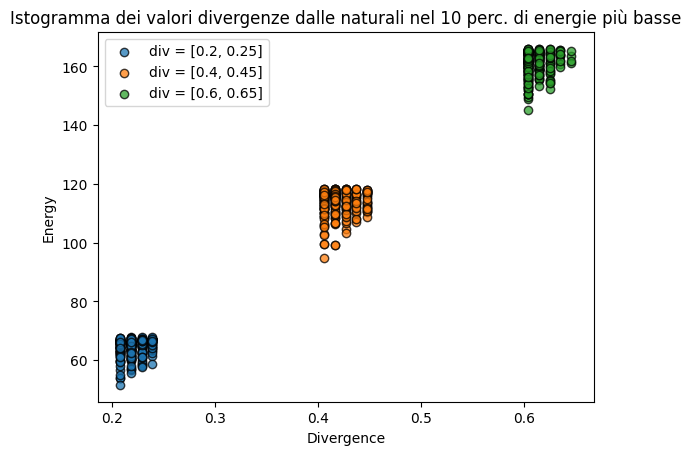

In [262]:
plt.scatter(div1_final, energies1_final, edgecolor='black', label="div = [0.2, 0.25]", alpha=0.75)
plt.scatter(div2_final, energies2_final, edgecolor='black', label="div = [0.4, 0.45]", alpha=0.75)
plt.scatter(div3_final, energies3_final, edgecolor='black', label="div = [0.6, 0.65]", alpha=0.75)

# Configurazione dell'istogramma
plt.title("Istogramma dei valori divergenze dalle naturali nel 10 perc. di energie più basse")
plt.xlabel("Divergence")
plt.ylabel("Energy")
plt.legend()
# Mostra il grafico
plt.show()

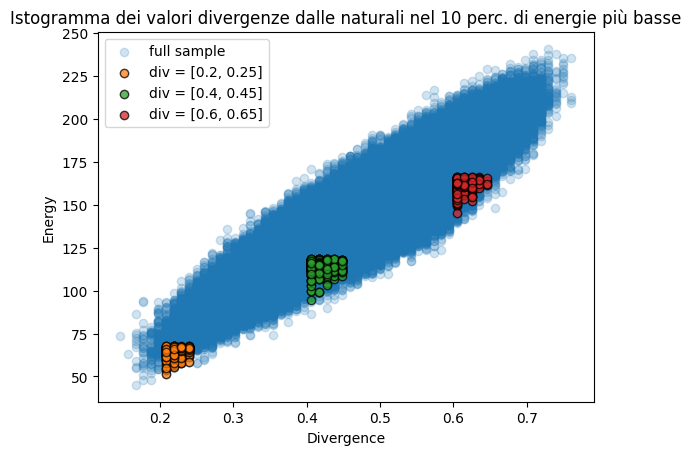

In [ ]:
random_indices = torch.randperm(sample.size(0))[:500_000] 


random_indices.shape
plt.scatter(divergence_cpu[random_indices], energies_cpu[random_indices], label="full sample", alpha=0.2)
plt.scatter(div1_final, energies1_final, edgecolor='black', label="div = [0.2, 0.25]", alpha=0.75)
plt.scatter(div2_final, energies2_final, edgecolor='black', label="div = [0.4, 0.45]", alpha=0.75)
plt.scatter(div3_final, energies3_final, edgecolor='black', label="div = [0.6, 0.65]", alpha=0.75)


# Configurazione dell'istogramma
plt.title("Istogramma dei valori divergenze dalle naturali nel 10 perc. di energie più basse")
plt.xlabel("divergence")
plt.ylabel("Energy")
plt.legend()
# Mostra il grafico
plt.show()

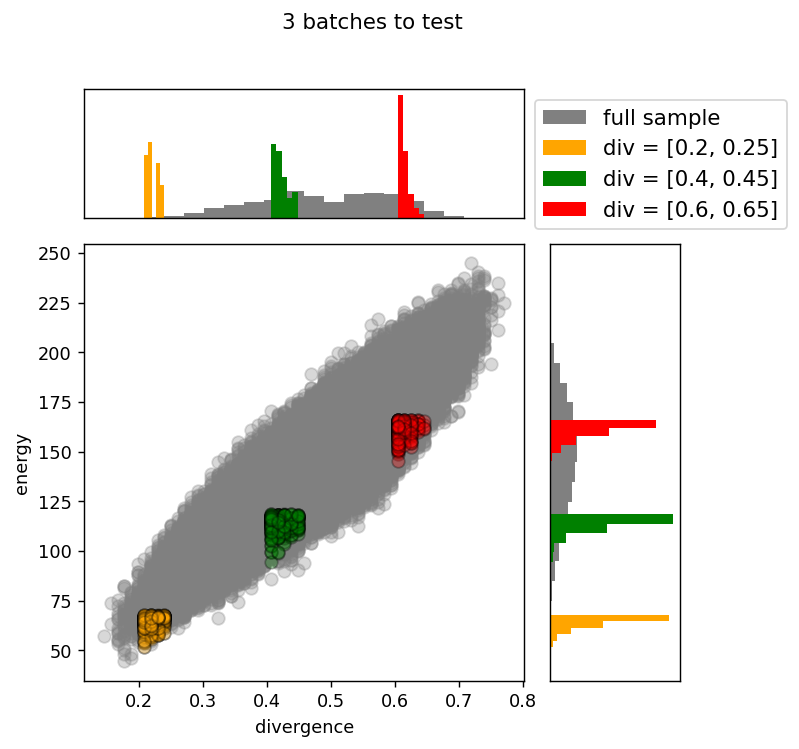

In [359]:
from matplotlib.gridspec import GridSpec

gs = GridSpec(4, 4)
title = "3 batches to test"
fig = plt.figure(figsize=(6, 6), dpi=128)
ax_scatter = fig.add_subplot(gs[1:4, 0:3])
ax_hist_x = fig.add_subplot(gs[0, 0:3])
ax_hist_y = fig.add_subplot(gs[1:4, 3])
    
N1 = 250
N2 = 500_000
random_indices = torch.randperm(sample.size(0))[:N2] 
ax_scatter.scatter(divergence_cpu[random_indices], energies_cpu[random_indices], color='grey', s=50, label="full sample", zorder=0, alpha=0.3)
ax_scatter.scatter(div1_final, energies1_final, edgecolor='black', color='orange', s=50, label="div = [0.2, 0.25]", zorder=0, alpha=0.3)
ax_scatter.scatter(div2_final, energies2_final, edgecolor='black', color='green',  s=50, label="div = [0.6, 0.45]", zorder=0, alpha=0.3)
ax_scatter.scatter(div3_final, energies3_final, edgecolor='black', color='red',    s=50, label="div = [0.6, 0.65]", zorder=0, alpha=0.3)


ax_hist_x.hist(divergence_cpu[random_indices], bins=20, color='grey', label="full sample", zorder=0, weights=np.ones(N2)/N2, orientation='vertical', lw=1)
ax_hist_x.hist(div1_final, bins=5, color='orange', label="div = [0.2, 0.25]", zorder=0,  weights=np.ones(N1)/N1, orientation='vertical', lw=1)
ax_hist_x.hist(div2_final, bins=5, color='green',  label="div = [0.4, 0.45]", zorder=0,  weights=np.ones(N1)/N1, orientation='vertical', lw=1)
ax_hist_x.hist(div3_final, bins=5, color='red',    label="div = [0.6, 0.65]", zorder=0,  weights=np.ones(N1)/N1, orientation='vertical', lw=1)

ax_hist_y.hist(energies_cpu[random_indices], bins=20, color='grey', label="full sample", zorder=0, weights=np.ones(N2)/N2, orientation='horizontal', lw=1)
ax_hist_y.hist(energies1_final, bins=5, color='orange', label="div = [0.2, 0.25]", zorder=0, weights=np.ones(N1)/N1, orientation='horizontal', lw=1)
ax_hist_y.hist(energies2_final, bins=5, color='green',  label="div = [0.6, 0.45]", zorder=0, weights=np.ones(N1)/N1, orientation='horizontal', lw=1)
ax_hist_y.hist(energies3_final, bins=5, color='red',    label="div = [0.6, 0.65]", zorder=0, weights=np.ones(N1)/N1, orientation='horizontal', lw=1)


ax_scatter.set_xlabel(f"divergence")
ax_scatter.set_ylabel(f"energy")

fig.suptitle(title)
ax_hist_x.set_xticks([])
ax_hist_y.set_xticks([])
ax_hist_x.set_yticks([])
ax_hist_y.set_yticks([])

ax_hist_x.legend(fontsize=12, bbox_to_anchor=(1, 1))
plt.savefig("energy_vs_divergence.png")

In [364]:
from scipy import stats
from sklearn.decomposition import PCA
# Set plot style for a cleaner visual appearance
import matplotlib.pyplot as plt


tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 1., 0.]], device='cuda:0')

In [438]:
pca = PCA(n_components=4)
pca.fit(nat_data.view(nat_data.size(0), -1).cpu())
nat_data_pca = pca.transform(nat_data.view(nat_data.size(0), -1).cpu())
sample_pca = pca.transform(sample.view(sample.size(0), -1).cpu())

In [439]:
batch1_final_pca = pca.transform(batch1_final.view(batch1_final.size(0), -1).cpu())
batch2_final_pca = pca.transform(batch2_final.view(batch2_final.size(0), -1).cpu())
batch3_final_pca = pca.transform(batch3_final.view(batch3_final.size(0), -1).cpu())

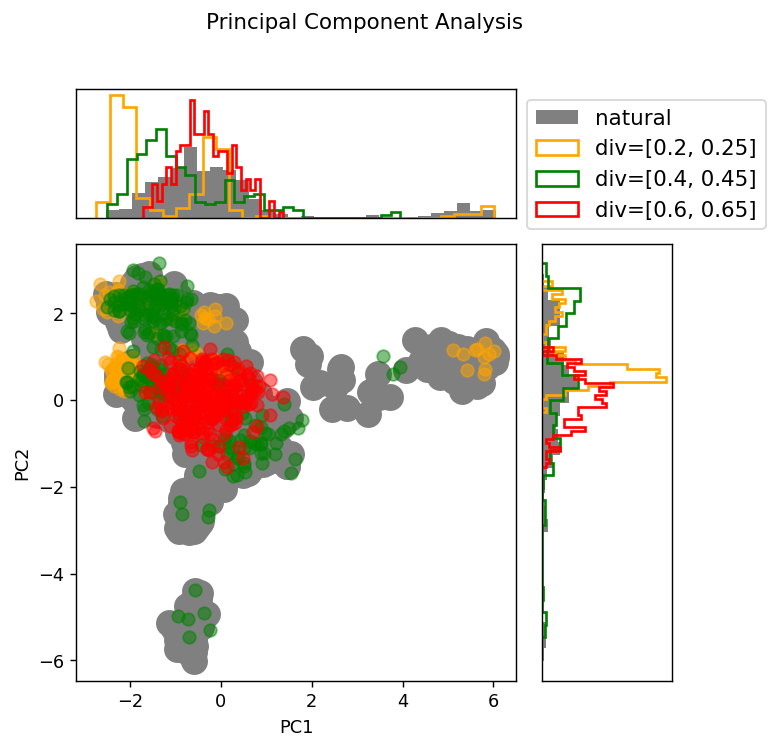

In [454]:
from matplotlib.gridspec import GridSpec


PC = [0, 1]

gs = GridSpec(4, 4)
title = "Principal Component Analysis"
fig = plt.figure(figsize=(6, 6), dpi=128)
ax_scatter = fig.add_subplot(gs[1:4, 0:3])
ax_hist_x = fig.add_subplot(gs[0, 0:3])
ax_hist_y = fig.add_subplot(gs[1:4, 3])
    
N2 = 2000
ax_scatter.scatter(nat_data_pca[:, PC[0]],     nat_data_pca[:, PC[1]],     color='grey',  s=200, zorder=0, alpha=1.0)
ax_scatter.scatter(batch1_final_pca[:, PC[0]], batch1_final_pca[:, PC[1]], color='orange',   s=50,  zorder=0, alpha=0.5)
ax_scatter.scatter(batch2_final_pca[:, PC[0]], batch2_final_pca[:, PC[1]], color='green',  s=50,  zorder=0, alpha=0.5)
ax_scatter.scatter(batch3_final_pca[:, PC[0]], batch3_final_pca[:, PC[1]], color='red', s=50,  zorder=0, alpha=0.5)


ax_hist_x.hist(nat_data_pca[:, PC[0]],     bins=30, color='grey',  label="natural",         zorder=0, density=True, orientation='vertical', lw=1)
ax_hist_x.hist(batch1_final_pca[:, PC[0]], bins=30, color='orange',   label="div=[0.2, 0.25]", zorder=1, density=True, orientation='vertical', lw=1.5, histtype='step')
ax_hist_x.hist(batch2_final_pca[:, PC[0]], bins=30, color='green',  label="div=[0.4, 0.45]", zorder=1, density=True, orientation='vertical', lw=1.5, histtype='step')
ax_hist_x.hist(batch3_final_pca[:, PC[0]], bins=30, color='red', label="div=[0.6, 0.65]", zorder=1, density=True, orientation='vertical', lw=1.5, histtype='step')

ax_hist_y.hist(nat_data_pca[:, PC[1]],     bins=30, color='grey',  zorder=0, density=True, orientation='horizontal', lw=1)
ax_hist_y.hist(batch1_final_pca[:, PC[1]], bins=30, color='orange',   zorder=1, density=True, orientation='horizontal', lw=1.5, histtype='step')
ax_hist_y.hist(batch2_final_pca[:, PC[1]], bins=30, color='green',  zorder=1, density=True, orientation='horizontal', lw=1.5, histtype='step')
ax_hist_y.hist(batch3_final_pca[:, PC[1]], bins=30, color='red', zorder=1, density=True, orientation='horizontal', lw=1.5, histtype='step')

ax_scatter.set_xlabel(f"PC{PC[0]+1}")
ax_scatter.set_ylabel(f"PC{PC[1]+1}")

fig.suptitle(title)
ax_hist_x.set_xticks([])
ax_hist_y.set_xticks([])
ax_hist_x.set_yticks([])
ax_hist_y.set_yticks([])

ax_hist_x.legend(fontsize=12, bbox_to_anchor=(1, 1))
plt.savefig("PCA_12.png")